In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
data = {
    "student_id":[1,2,3,4,5,6,7,8,9,10],
    "GPA":[3.5,2.8,3.9,2.5,3.2,3.8,2.2,3.0,3.6,2.7],
    "study_hours":[25,15,30,10,20,28,8,18,26,14],
    "attendance_rate":[90,75,95,60,85,92,55,80,88,70]
}

df = pd.DataFrame(data)

df.head()

,student_id,GPA,study_hours,attendance_rate
0,1,3.5,25,90
1,2,2.8,15,75
2,3,3.9,30,95
3,4,2.5,10,60
4,5,3.2,20,85


In [3]:
X = df[["GPA","study_hours","attendance_rate"]]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
wcss = []

for i in range(2,7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

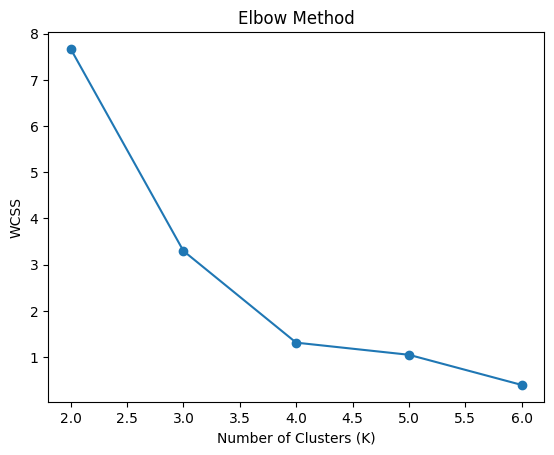

In [6]:
plt.plot(range(2,7), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [8]:
df["Cluster"] = clusters

In [9]:
print(df[["student_id","Cluster"]])

   student_id  Cluster
0           1        1
1           2        2
2           3        1
3           4        0
4           5        1
5           6        1
6           7        0
7           8        2
8           9        1
9          10        2


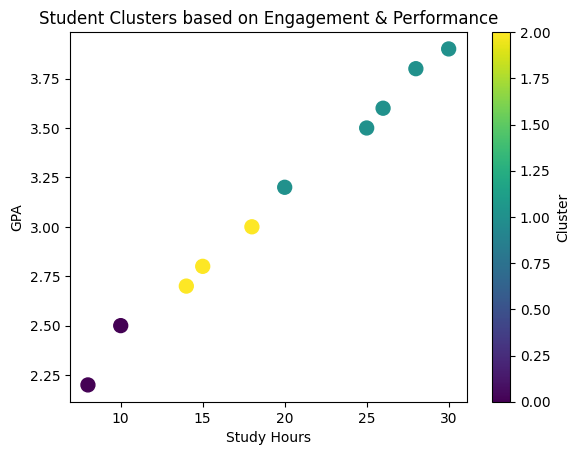

In [10]:
plt.figure()

plt.scatter(df["study_hours"],
            df["GPA"],
            c=df["Cluster"],
            cmap="viridis",
            s=100)

plt.title("Student Clusters based on Engagement & Performance")
plt.xlabel("Study Hours")
plt.ylabel("GPA")

plt.colorbar(label="Cluster")
plt.show()